# NumPy Fundamentals for Data Science

Este notebook faz parte do meu portfólio de Data Science (Dia 2 / Fase 1 — Python Basics).

**NumPy** (*Numerical Python*) é a biblioteca fundamental para computação numérica em Python.
Ela fornece o objeto `ndarray` — um array N-dimensional altamente eficiente — que serve de base
para praticamente todo o ecossistema de Data Science (pandas, scikit-learn, matplotlib, etc.).

Aqui exploramos criação de arrays, indexação, operações vetorizadas, broadcasting, estatística,
álgebra linear e uma aplicação prática conectada ao meu background em **Linguística/NLP**:
representação vetorial de texto e similaridade de cosseno com NumPy puro.

## 🎯 Objetivos de Aprendizado

Ao final deste notebook, você será capaz de:

1. **Criar arrays** de diferentes formas (`np.array`, `zeros`, `ones`, `arange`, `linspace`, `random`).
2. **Indexar e fatiar** arrays 1D, 2D e 3D, incluindo *boolean* e *fancy indexing*.
3. Aplicar **operações vetorizadas** e entender as regras de **broadcasting**.
4. Usar **funções universais** (ufuncs) e **operações estatísticas** com o parâmetro `axis`.
5. Executar **álgebra linear** básica (produto matricial, norma, determinante, inversa, autovalores).
6. Aplicar NumPy a um **dataset real** e construir uma representação **bag-of-words** de texto.
7. Comparar o **desempenho** de NumPy vs listas Python puras.
8. **Visualizar** distribuições e matrizes de correlação.

In [1]:
# Core scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 1.26.4
Pandas version: 2.2.3


## 1. Array Creation

Existem várias formas de criar arrays NumPy. As mais comuns partem de listas Python ou de
funções geradoras (`zeros`, `ones`, `arange`, `linspace`). Todo array tem dois atributos-chave:
- `shape`: a forma (dimensões) do array;
- `dtype`: o tipo de dado dos elementos (ex.: `int64`, `float64`).

In [2]:
# Creating arrays from Python lists
a = np.array([1, 2, 3, 4, 5])
b = np.array([[1, 2, 3], [4, 5, 6]])  # 2D array (matrix)

print("1D array a:", a)
print("shape:", a.shape, "| dtype:", a.dtype, "| ndim:", a.ndim)
print()
print("2D array b:\n", b)
print("shape:", b.shape, "| dtype:", b.dtype, "| ndim:", b.ndim)

1D array a: [1 2 3 4 5]
shape: (5,) | dtype: int64 | ndim: 1

2D array b:
 [[1 2 3]
 [4 5 6]]
shape: (2, 3) | dtype: int64 | ndim: 2


In [3]:
# Generator functions
zeros = np.zeros((2, 3))          # matrix of zeros
ones = np.ones((3, 3))            # matrix of ones
rng = np.arange(0, 10, 2)         # start, stop, step -> [0 2 4 6 8]
lin = np.linspace(0, 1, 5)        # 5 evenly spaced points between 0 and 1
eye = np.eye(3)                   # identity matrix

print("zeros((2,3)):\n", zeros)
print("\nones((3,3)):\n", ones)
print("\narange(0,10,2):", rng)
print("linspace(0,1,5):", lin)
print("\nidentity eye(3):\n", eye)

zeros((2,3)):
 [[0. 0. 0.]
 [0. 0. 0.]]

ones((3,3)):
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

arange(0,10,2): [0 2 4 6 8]
linspace(0,1,5): [0.   0.25 0.5  0.75 1.  ]

identity eye(3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [4]:
# Random arrays (reproducible with a fixed seed)
np.random.seed(42)

randn = np.random.randn(3, 3)              # standard normal distribution
randint = np.random.randint(0, 100, size=8)  # integers in [0, 100)
uniform = np.random.rand(5)               # uniform [0, 1)

print("randn (3x3):\n", np.round(randn, 3))
print("\nrandint 0-100:", randint)
print("uniform [0,1):", np.round(uniform, 3))

randn (3x3):
 [[ 0.497 -0.138  0.648]
 [ 1.523 -0.234 -0.234]
 [ 1.579  0.767 -0.469]]

randint 0-100: [63 59 20 32 75 57 21 88]
uniform [0,1): [0.291 0.612 0.139 0.292 0.366]


## 2. Array Indexing & Slicing

A indexação em NumPy é poderosa e vai muito além das listas Python. Podemos:
- indexar por posição em múltiplas dimensões (`arr[row, col]`);
- fatiar (`arr[start:stop:step]`);
- usar **boolean indexing** (filtrar por condição);
- usar **fancy indexing** (selecionar por listas de índices).

In [5]:
# 1D indexing and slicing
arr = np.arange(10, 20)
print("arr:", arr)
print("arr[0]:", arr[0], "| arr[-1]:", arr[-1])
print("arr[2:6]:", arr[2:6])
print("arr[::2] (every 2nd):", arr[::2])
print("arr[::-1] (reversed):", arr[::-1])

arr: [10 11 12 13 14 15 16 17 18 19]
arr[0]: 10 | arr[-1]: 19
arr[2:6]: [12 13 14 15]
arr[::2] (every 2nd): [10 12 14 16 18]
arr[::-1] (reversed): [19 18 17 16 15 14 13 12 11 10]


In [6]:
# 2D and 3D indexing
mat = np.arange(1, 13).reshape(3, 4)
print("2D matrix (3x4):\n", mat)
print("\nElement [1,2]:", mat[1, 2])
print("Row 0:", mat[0])
print("Column 2:", mat[:, 2])
print("Sub-block [0:2, 1:3]:\n", mat[0:2, 1:3])

cube = np.arange(24).reshape(2, 3, 4)  # 3D array
print("\n3D array shape:", cube.shape)
print("cube[1, 2, 3]:", cube[1, 2, 3])

2D matrix (3x4):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Element [1,2]: 7
Row 0: [1 2 3 4]
Column 2: [ 3  7 11]
Sub-block [0:2, 1:3]:
 [[2 3]
 [6 7]]

3D array shape: (2, 3, 4)
cube[1, 2, 3]: 23


In [7]:
# Boolean indexing and fancy indexing
data = np.array([15, 3, 27, 8, 42, 19, 6])

mask = data > 15
print("data:", data)
print("mask (data > 15):", mask)
print("data[mask]:", data[mask])          # boolean indexing
print("Mean of values > 15:", data[data > 15].mean())

# Fancy indexing: pick specific positions in a chosen order
idx = [0, 4, 6]
print("\nFancy indexing data[[0,4,6]]:", data[idx])

data: [15  3 27  8 42 19  6]
mask (data > 15): [False False  True False  True  True False]
data[mask]: [27 42 19]
Mean of values > 15: 29.333333333333332

Fancy indexing data[[0,4,6]]: [15 42  6]


## 3. Array Operations & Broadcasting

Operações em NumPy são **vetorizadas**: aplicadas elemento a elemento sem loops explícitos em Python.
O **broadcasting** é o conjunto de regras que permite operar arrays de formas diferentes,
"esticando" a dimensão menor para casar com a maior — sem copiar dados na memória.

**Regra do broadcasting:** comparando as dimensões de trás para frente, elas são compatíveis
quando são iguais ou uma delas é 1.

In [8]:
# Element-wise arithmetic (vectorized)
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])

print("x + y:", x + y)
print("x * y:", x * y)
print("y / x:", y / x)
print("x ** 2:", x ** 2)
print("x + 100 (scalar broadcast):", x + 100)

x + y: [11 22 33 44]
x * y: [ 10  40  90 160]
y / x: [10. 10. 10. 10.]
x ** 2: [ 1  4  9 16]
x + 100 (scalar broadcast): [101 102 103 104]


In [9]:
# Broadcasting: matrix (3x3) + row vector (3,)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
row = np.array([10, 20, 30])
col = np.array([[100], [200], [300]])  # shape (3,1)

print("matrix + row (broadcast over rows):\n", matrix + row)
print("\nmatrix + col (broadcast over columns):\n", matrix + col)
print("\nShapes -> matrix:", matrix.shape, "row:", row.shape, "col:", col.shape)

matrix + row (broadcast over rows):
 [[11 22 33]
 [14 25 36]
 [17 28 39]]

matrix + col (broadcast over columns):
 [[101 102 103]
 [204 205 206]
 [307 308 309]]

Shapes -> matrix: (3, 3) row: (3,) col: (3, 1)


In [10]:
# Universal functions (ufuncs) operate element-wise and fast
values = np.array([1, 4, 9, 16, 25], dtype=float)

print("sqrt:", np.sqrt(values))
print("exp :", np.round(np.exp([0, 1, 2]), 3))
print("log :", np.round(np.log(values), 3))
print("abs :", np.abs([-3, -1, 2, -5]))
print("sin :", np.round(np.sin(np.linspace(0, np.pi, 5)), 3))

sqrt: [1. 2. 3. 4. 5.]
exp : [1.    2.718 7.389]
log : [0.    1.386 2.197 2.773 3.219]
abs : [3 1 2 5]
sin : [0.    0.707 1.    0.707 0.   ]


In [11]:
# Reshaping and combining arrays
base = np.arange(12)
reshaped = base.reshape(3, 4)
print("Original:", base)
print("Reshaped (3x4):\n", reshaped)
print("Transposed (4x3):\n", reshaped.T)
print("Flattened:", reshaped.flatten())

# Stacking
a1 = np.array([1, 2, 3])
a2 = np.array([4, 5, 6])
print("\nvstack:\n", np.vstack([a1, a2]))
print("hstack:", np.hstack([a1, a2]))

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Reshaped (3x4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Transposed (4x3):
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]

vstack:
 [[1 2 3]
 [4 5 6]]
hstack: [1 2 3 4 5 6]


## 4. Statistical Operations

NumPy oferece funções estatísticas rápidas. O parâmetro **`axis`** controla a direção do cálculo:
- `axis=0` → opera ao longo das **linhas** (resultado por coluna);
- `axis=1` → opera ao longo das **colunas** (resultado por linha);
- sem `axis` → opera sobre o array inteiro (achatado).

In [12]:
# Descriptive statistics
np.random.seed(0)
sample = np.random.randn(1000) * 15 + 100   # mean~100, std~15

print(f"mean       : {np.mean(sample):.3f}")
print(f"median     : {np.median(sample):.3f}")
print(f"std        : {np.std(sample):.3f}")
print(f"var        : {np.var(sample):.3f}")
print(f"min / max  : {np.min(sample):.3f} / {np.max(sample):.3f}")
print(f"25th pct   : {np.percentile(sample, 25):.3f}")
print(f"75th pct   : {np.percentile(sample, 75):.3f}")

mean       : 99.321
median     : 99.130
std        : 14.805
var        : 219.203
min / max  : 54.308 / 141.390
25th pct   : 89.524
75th pct   : 109.104


In [13]:
# argmin / argmax return the INDEX of the min/max
scores = np.array([88, 72, 95, 61, 90])
print("scores:", scores)
print("argmax (best index):", np.argmax(scores), "-> value", scores[np.argmax(scores)])
print("argmin (worst index):", np.argmin(scores), "-> value", scores[np.argmin(scores)])

scores: [88 72 95 61 90]
argmax (best index): 2 -> value 95
argmin (worst index): 3 -> value 61


In [14]:
# Axis-based statistics on a 2D array
grid = np.array([[ 1,  2,  3],
                 [ 4,  5,  6],
                 [ 7,  8,  9],
                 [10, 11, 12]])
print("grid:\n", grid)
print("\nSum over all:", grid.sum())
print("Sum axis=0 (per column):", grid.sum(axis=0))
print("Sum axis=1 (per row)   :", grid.sum(axis=1))
print("Mean axis=0 (per column):", grid.mean(axis=0))

grid:
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

Sum over all: 78
Sum axis=0 (per column): [22 26 30]
Sum axis=1 (per row)   : [ 6 15 24 33]
Mean axis=0 (per column): [5.5 6.5 7.5]


## 5. Linear Algebra

NumPy integra rotinas de álgebra linear (via `np.linalg`), essenciais para Machine Learning:
produto matricial, norma de vetores, determinante, inversa e autovalores/autovetores.

In [15]:
# Matrix multiplication: dot, matmul and the @ operator
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("np.dot(A, B):\n", np.dot(A, B))
print("\nnp.matmul(A, B):\n", np.matmul(A, B))
print("\nA @ B (operator):\n", A @ B)

v = np.array([1, 2, 3])
print("\nDot product of vectors:", np.dot(v, v))

np.dot(A, B):
 [[19 22]
 [43 50]]

np.matmul(A, B):
 [[19 22]
 [43 50]]

A @ B (operator):
 [[19 22]
 [43 50]]

Dot product of vectors: 14


In [16]:
# Norm, determinant and inverse
M = np.array([[4.0, 7.0],
              [2.0, 6.0]])

print("L2 norm of [3,4]:", np.linalg.norm([3, 4]))   # -> 5.0
print("Determinant of M:", np.linalg.det(M))
inv = np.linalg.inv(M)
print("Inverse of M:\n", np.round(inv, 3))
print("\nCheck M @ inv(M) ~ Identity:\n", np.round(M @ inv, 6))

L2 norm of [3,4]: 5.0
Determinant of M: 10.000000000000002
Inverse of M:
 [[ 0.6 -0.7]
 [-0.2  0.4]]

Check M @ inv(M) ~ Identity:
 [[ 1. -0.]
 [-0.  1.]]


In [17]:
# Eigenvalues and eigenvectors
S = np.array([[2, 0],
              [0, 3]])
eigenvalues, eigenvectors = np.linalg.eig(S)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# Solving a linear system Ax = b
Acoef = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
x = np.linalg.solve(Acoef, b)
print("\nSolution of Ax=b:", x)

Eigenvalues: [2. 3.]
Eigenvectors:
 [[1. 0.]
 [0. 1.]]

Solution of Ax=b: [2. 3.]


## 6. Aplicação Real: Dados e Linguagem 🗣️

Aqui conecto NumPy ao meu background em **Linguística/NLP aplicado à educação**.

Primeiro carregamos um **dataset real** (`iris`, via seaborn) e usamos NumPy para análise estatística.
Em seguida construímos manualmente uma representação **bag-of-words** de frases curtas
(um corpus mínimo do tipo que aparece em materiais de ensino de inglês) e calculamos a
**similaridade de cosseno** entre elas — tudo com NumPy puro.

In [18]:
# Load a REAL dataset (Iris) and convert numeric features to a NumPy array
iris = sns.load_dataset("iris")
print(iris.head())

features = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]].to_numpy()
print("\nFeature matrix shape:", features.shape, "| dtype:", features.dtype)

# NumPy statistics per feature (axis=0 -> per column)
print("\nMean per feature :", np.round(features.mean(axis=0), 3))
print("Std  per feature :", np.round(features.std(axis=0), 3))
print("Min  per feature :", features.min(axis=0))
print("Max  per feature :", features.max(axis=0))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Feature matrix shape: (150, 4) | dtype: float64

Mean per feature : [5.843 3.057 3.758 1.199]
Std  per feature : [0.825 0.434 1.759 0.76 ]
Min  per feature : [4.3 2.  1.  0.1]
Max  per feature : [7.9 4.4 6.9 2.5]


In [19]:
# Standardize the features with NumPy (z-score) -> common ML preprocessing step
means = features.mean(axis=0)
stds = features.std(axis=0)
standardized = (features - means) / stds   # broadcasting in action

print("Standardized means (~0):", np.round(standardized.mean(axis=0), 6))
print("Standardized stds  (~1):", np.round(standardized.std(axis=0), 6))

Standardized means (~0): [-0. -0. -0. -0.]
Standardized stds  (~1): [1. 1. 1. 1.]


In [20]:
# Manual Bag-of-Words with NumPy — connecting to my linguistics background.
# A tiny corpus of the kind used in English-teaching materials:
corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "the student reads a book",
    "the teacher reads a book to the student",
]

# Build the vocabulary (unique words, sorted)
vocab = sorted(set(word for sentence in corpus for word in sentence.split()))
word_to_idx = {w: i for i, w in enumerate(vocab)}
print("Vocabulary size:", len(vocab))
print("Vocabulary:", vocab)

# Build the document-term matrix (rows=documents, cols=word counts) with NumPy
bow = np.zeros((len(corpus), len(vocab)), dtype=int)
for row, sentence in enumerate(corpus):
    for word in sentence.split():
        bow[row, word_to_idx[word]] += 1

print("\nBag-of-Words matrix shape:", bow.shape)
print(bow)

Vocabulary size: 13
Vocabulary: ['a', 'book', 'cat', 'dog', 'log', 'mat', 'on', 'reads', 'sat', 'student', 'teacher', 'the', 'to']

Bag-of-Words matrix shape: (4, 13)
[[0 0 1 0 0 1 1 0 1 0 0 2 0]
 [0 0 0 1 1 0 1 0 1 0 0 2 0]
 [1 1 0 0 0 0 0 1 0 1 0 1 0]
 [1 1 0 0 0 0 0 1 0 1 1 2 1]]


In [21]:
# Cosine similarity between text vectors, implemented with pure NumPy
def cosine_similarity(u, v):
    """Return the cosine similarity between two 1D vectors."""
    denom = np.linalg.norm(u) * np.linalg.norm(v)
    return float(np.dot(u, v) / denom) if denom else 0.0

# Compare every pair of documents
n_docs = bow.shape[0]
sim_matrix = np.zeros((n_docs, n_docs))
for i in range(n_docs):
    for j in range(n_docs):
        sim_matrix[i, j] = cosine_similarity(bow[i], bow[j])

print("Cosine similarity matrix (document vs document):\n", np.round(sim_matrix, 3))
print("\nMost similar pair to doc 0:")
row0 = sim_matrix[0].copy()
row0[0] = -1  # ignore self-similarity
best = np.argmax(row0)
print(f"  Doc 0: '{corpus[0]}'")
print(f"  Doc {best}: '{corpus[best]}'  (similarity={sim_matrix[0, best]:.3f})")

Cosine similarity matrix (document vs document):
 [[1.    0.75  0.316 0.447]
 [0.75  1.    0.316 0.447]
 [0.316 0.316 1.    0.849]
 [0.447 0.447 0.849 1.   ]]

Most similar pair to doc 0:
  Doc 0: 'the cat sat on the mat'
  Doc 1: 'the dog sat on the log'  (similarity=0.750)


## 7. Performance: NumPy vs Listas Python

A grande vantagem do NumPy é a **vetorização**: operações são executadas em C otimizado,
evitando o overhead de loops em Python. Vamos medir o *speedup* somando um milhão de elementos.

In [22]:
import time

n = 1_000_000
py_list = list(range(n))
np_array = np.arange(n)

# Pure Python loop
start = time.time()
py_sum = sum(x * 2 for x in py_list)
py_time = time.time() - start

# Vectorized NumPy
start = time.time()
np_sum = (np_array * 2).sum()
np_time = time.time() - start

print(f"Python list time : {py_time*1000:.2f} ms")
print(f"NumPy array time : {np_time*1000:.2f} ms")
print(f"Speedup          : {py_time / np_time:.1f}x faster with NumPy")
print(f"Results match    : {py_sum == np_sum}")

Python list time : 26.36 ms
NumPy array time : 5.06 ms
Speedup          : 5.2x faster with NumPy
Results match    : True


In [23]:
# %timeit gives a more robust benchmark by averaging many runs
print("Python list comprehension:")
%timeit [x * 2 for x in py_list]
print("\nNumPy vectorized:")
%timeit np_array * 2

Python list comprehension:


28.2 ms ± 1.51 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

NumPy vectorized:


537 μs ± 3.47 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 8. Visualização

Por fim, usamos matplotlib e seaborn para visualizar dados gerados/analisados com NumPy:
uma distribuição normal e um *heatmap* de correlação das features do dataset Iris.

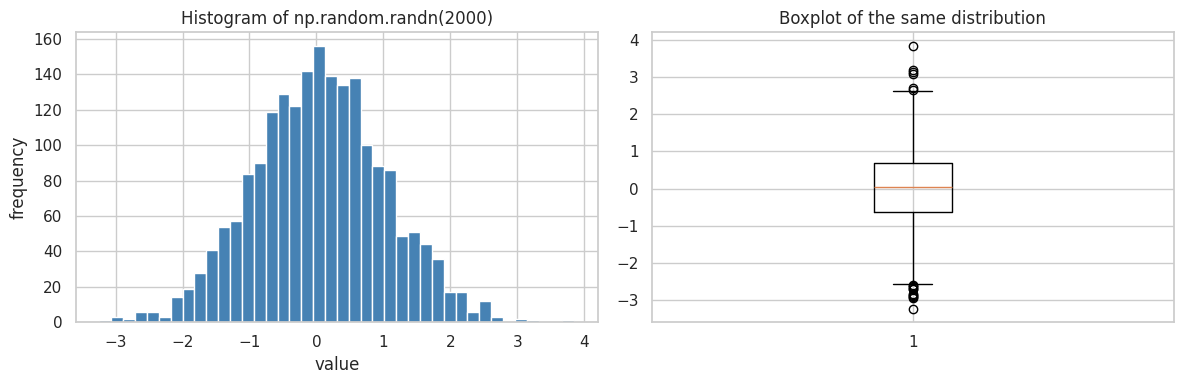

In [24]:
# Visualize a NumPy-generated normal distribution
np.random.seed(42)
normal_data = np.random.randn(2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(normal_data, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Histogram of np.random.randn(2000)")
axes[0].set_xlabel("value"); axes[0].set_ylabel("frequency")

axes[1].boxplot(normal_data, vert=True)
axes[1].set_title("Boxplot of the same distribution")
plt.tight_layout()
plt.show()

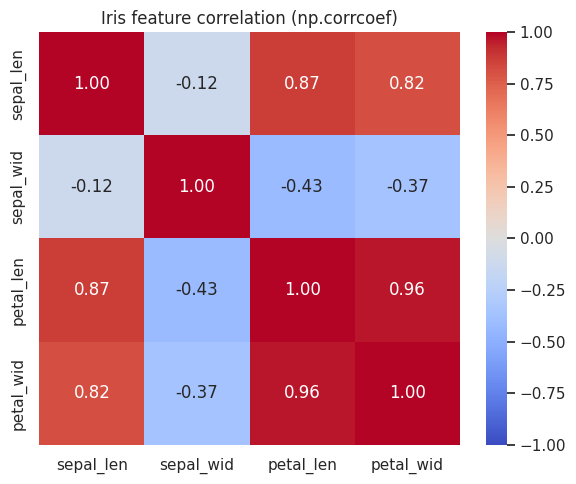

In [25]:
# Correlation matrix of Iris features, computed with NumPy and shown as a heatmap
corr = np.corrcoef(features, rowvar=False)   # rowvar=False -> columns are variables
labels = ["sepal_len", "sepal_wid", "petal_len", "petal_wid"]

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=labels, yticklabels=labels, vmin=-1, vmax=1)
plt.title("Iris feature correlation (np.corrcoef)")
plt.tight_layout()
plt.show()

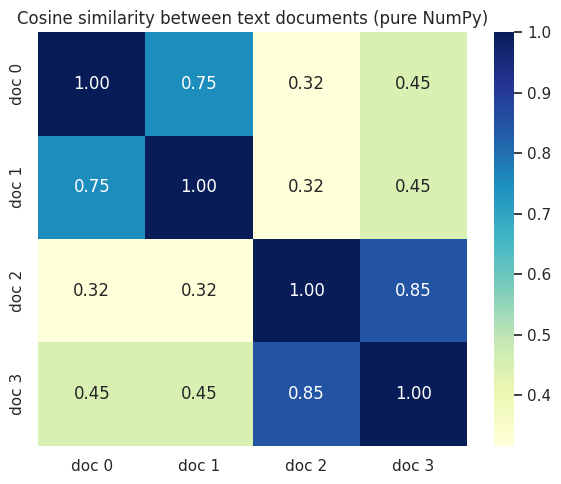

In [26]:
# Bonus: visualize the text cosine-similarity matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[f"doc {i}" for i in range(n_docs)],
            yticklabels=[f"doc {i}" for i in range(n_docs)])
plt.title("Cosine similarity between text documents (pure NumPy)")
plt.tight_layout()
plt.show()

## ✅ Resumo e Próximos Passos

Neste notebook cobrimos os fundamentos do **NumPy**:

- **Criação de arrays** com `array`, `zeros`, `ones`, `arange`, `linspace` e módulos random.
- **Indexação/slicing** 1D–3D, incluindo *boolean* e *fancy indexing*.
- **Operações vetorizadas** e **broadcasting** — o coração da performance do NumPy.
- **ufuncs** e **estatística** com o parâmetro `axis`.
- **Álgebra linear**: produto matricial, norma, determinante, inversa e autovalores.
- **Aplicação em NLP**: bag-of-words manual e **similaridade de cosseno** com NumPy puro.
- **Benchmark** demonstrando o *speedup* frente a listas Python.
- **Visualização** de distribuições e matrizes de correlação.

### 🔜 Próximos passos (Fase 1)
- Aprofundar **pandas** para manipulação de dados tabulares.
- Explorar **matplotlib/seaborn** para EDA (Fase 2).
- Aplicar essas bases numéricas em **pré-processamento de texto** para projetos de NLP educacional.

*Portfólio de Data Science — Gutemberg Rapôso | Linguística × Data Science × NLP*